# Financial Sales Performance Analysis

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to analyze the cleaned financial sales dataset to identify trends, evaluate business performance, and generate actionable insights through visualizations and statistical analysis.

---

### Business Questions

1. What are the key business KPIs?
2. Which country generates the highest sales and profit?
3. Which customer segment contributes the most revenue?
4. Which products perform best?
5. How do discounts affect profitability?
6. What trends can be observed over time?
7. What recommendations can improve business performance?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_excel("../data/financial_sales_cleaned.xlsx")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


## 1. Executive KPI Summary

The following KPIs provide a high-level overview of the company's financial performance.

In [4]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
gross_sales = df["Gross Sales"].sum()
units_sold = df["Units Sold"].sum()
total_discounts = df["Discounts"].sum()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Gross Sales: ${gross_sales:,.2f}")
print(f"Units Sold: {units_sold:,.0f}")
print(f"Total Discounts: ${total_discounts:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: $118,726,350.26
Total Profit: $16,893,702.26
Gross Sales: $127,931,598.50
Units Sold: 1,125,806
Total Discounts: $9,205,248.24
Profit Margin: 14.23%


## Executive KPI Insights

### Key Findings

- The company generated **$118.73 million** in total sales.
- Overall profit reached **$16.89 million**, resulting in a **14.23% profit margin**.
- More than **1.12 million units** were sold during the analysis period.
- Discounts totaling **$9.21 million** were provided to customers.
- Gross sales exceeded **$127.93 million**, indicating that discounts reduced revenue by approximately **$9.21 million**.

These KPIs provide a high-level overview of business performance and serve as the foundation for further analysis.

# 2. Sales Performance by Country

## Business Question

1. Which countries contribute the most to overall sales revenue?

Understanding regional performance helps management identify strong markets and prioritize future business investments.

In [5]:
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

country_sales

Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64

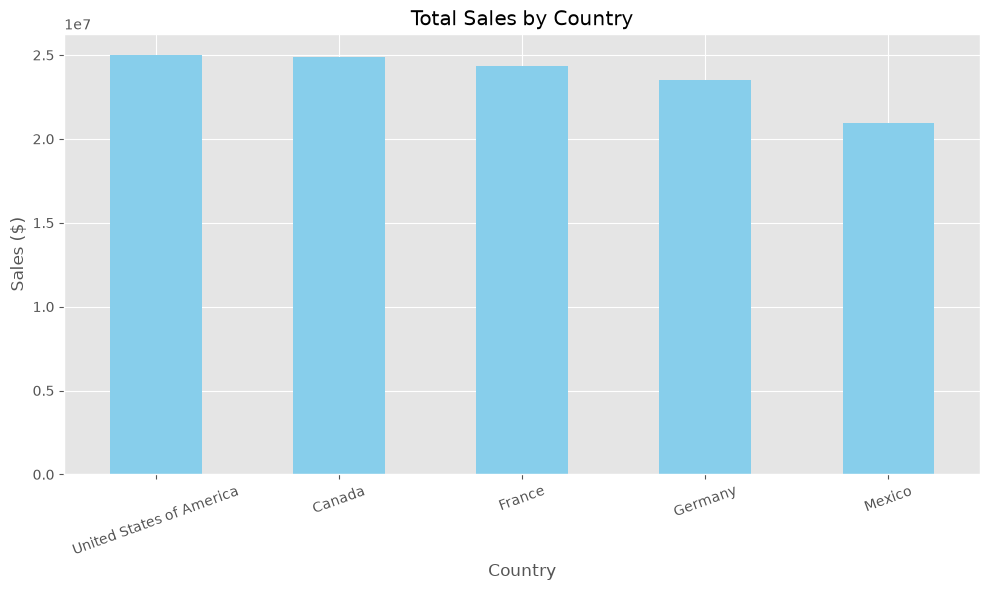

In [16]:
plt.figure(figsize=(10,6))

country_sales.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales ($)")
plt.xticks(rotation=20)


country_sales.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales ($)")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# 3. Profit Analysis by Country

## Business Question

Which countries generate the highest profit?

While sales indicate revenue generation, profit reflects business sustainability. This analysis helps identify the most profitable markets.

In [17]:
country_profit = (
    df.groupby("Country")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

country_profit

Country
France                      3781020.780
Germany                     3680388.820
Canada                      3529228.885
United States of America    2995540.665
Mexico                      2907523.110
Name: Profit, dtype: float64

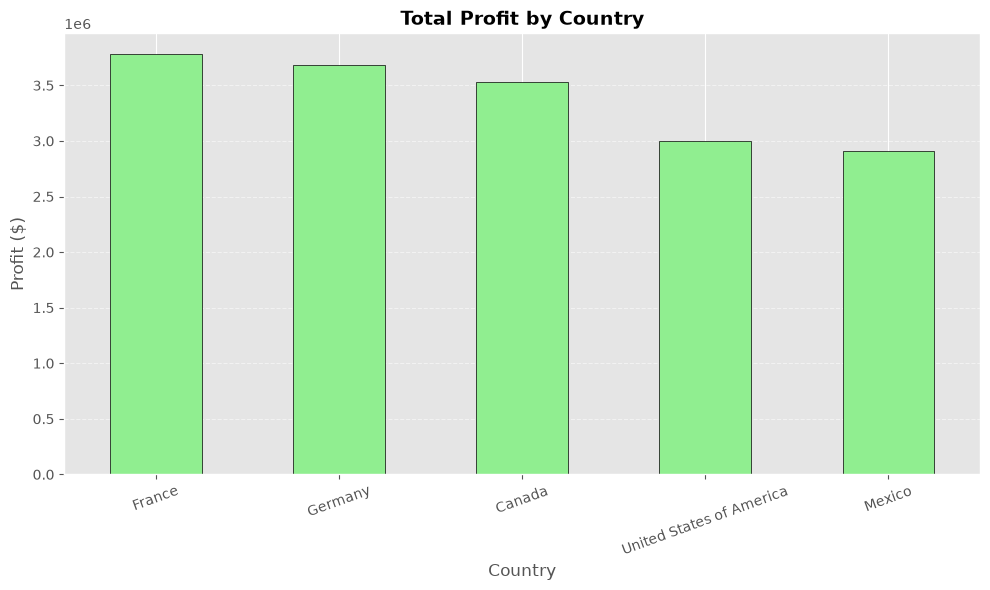

In [22]:
plt.figure(figsize=(10,6))

country_profit.plot(
    kind="bar",
    color="lightgreen",
    edgecolor="black"
)

plt.title("Total Profit by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Profit ($)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Investigation
here US has the highest sales, why isn't it the most profitable?

In [23]:
country_analysis = df.groupby("Country").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum"),
    Total_Discounts=("Discounts", "sum")
)

country_analysis["Profit_Margin (%)"] = (
    country_analysis["Total_Profit"] /
    country_analysis["Total_Sales"] * 100
).round(2)

country_analysis.sort_values("Total_Profit", ascending=False)

,Total_Sales,Total_Profit,Units_Sold,Total_Discounts,Profit_Margin (%)
Country,,,,,
France,2.435417e+07,3781020.780,240931.0,1727502.220,15.53
Germany,2.350534e+07,3680388.820,201494.0,1416126.680,15.66
Canada,2.488765e+07,3529228.885,247428.5,2044508.615,14.18
United States of America,2.502983e+07,2995540.665,232627.5,2239527.835,11.97
Mexico,2.094935e+07,2907523.110,203325.0,1777582.890,13.88


Although the United States generated the highest sales revenue, France achieved significantly higher profitability. The analysis indicates that the United States offered the largest total discounts ($2.24M), which reduced its profit margin to 11.97%, compared to France's 15.53%.

In [24]:
pd.pivot_table(
    df,
    values="Profit",
    index="Country",
    columns="Product",
    aggfunc="sum"
).round(2)

Product,Amarilla,Carretera,Montana,Paseo,VTT,Velo
Country,,,,,,
Canada,646861.38,436105.34,321867.03,1265017.99,488808.81,370568.34
France,667867.63,388864.90,461238.37,838748.56,716371.09,707930.24
Germany,612137.26,369674.68,559438.37,744416.74,605932.77,788789.00
Mexico,498611.39,393668.42,337689.31,928651.39,575598.71,173303.89
United States of America,388626.40,238491.55,434521.80,1020603.27,647896.64,265401.00


In [25]:
pd.pivot_table(
    df,
    values="Profit",
    index="Country",
    columns="Segment",
    aggfunc="sum"
).round(2)

Segment,Channel Partners,Enterprise,Government,Midmarket,Small Business
Country,,,,,
Canada,358978.14,-121508.75,2258471.52,132488.98,900799.0
France,271581.36,-95749.38,2709915.22,164542.08,730731.5
Germany,247358.88,-101473.75,2677175.94,85354.75,771973.0
Mexico,170890.08,-120678.75,2039159.38,150546.40,667606.0
United States of America,267994.68,-175135.00,1703451.11,127170.88,1072059.0


## Insight Investigation: Why is France More Profitable than the United States?

### Objective

Although the United States recorded the highest total sales, France generated the highest overall profit. This section investigates the factors contributing to this difference.

---

### Findings

#### 1. Higher Sales Do Not Always Mean Higher Profit

The United States generated the highest total sales (**$25.03M**), while France recorded slightly lower sales (**$24.35M**). However, France achieved the highest total profit (**$3.78M**) compared to the United States (**$3.00M**).

This indicates that higher revenue does not necessarily translate into higher profitability.

---

#### 2. Discount Strategy Affected Profitability

The United States provided the highest total discounts (**$2.24M**) among all countries, whereas France offered lower total discounts (**$1.73M**).

As a result, the United States achieved a lower profit margin (**11.97%**) compared to France (**15.53%**). This suggests that aggressive discounting reduced overall profitability.

---

#### 3. Government Segment Was the Major Profit Contributor

The Government segment generated the largest share of profits across all countries.

France earned approximately **$2.71M** from Government customers, significantly higher than the United States, which generated approximately **$1.70M**.

This strong Government segment performance was one of the primary reasons France became the most profitable country.

---

#### 4. Enterprise Segment Was Unprofitable

The Enterprise segment recorded negative profits in every country.

The United States experienced the largest Enterprise loss (approximately **-$175K**), indicating potential issues related to pricing, operational costs, or discount policies within this customer segment.

---

#### 5. Product Portfolio Differences

France generated strong profits across multiple products, including Amarilla, Paseo, VTT, and Velo, indicating a well-balanced product portfolio.

In comparison, the United States relied heavily on Paseo for profitability, while several other products contributed comparatively lower profits.

A diversified product mix may have helped France maintain stronger overall profitability.

---

### Business Insights

- High sales volume alone is not sufficient to maximize profit.
- Excessive discounting can significantly reduce profit margins.
- The Government segment is the strongest profit-generating customer segment.
- The Enterprise segment requires detailed business review due to consistent losses.
- Maintaining a diversified product portfolio can improve long-term profitability and reduce dependence on a single product.

---

### Recommendations

- Review the discount strategy in the United States to improve profit margins.
- Investigate pricing, costs, and discount policies within the Enterprise segment.
- Analyze the successful Government segment strategy implemented in France and evaluate opportunities to replicate similar practices in other regions.
- Promote a balanced product portfolio to reduce reliance on individual products and improve overall profitability.

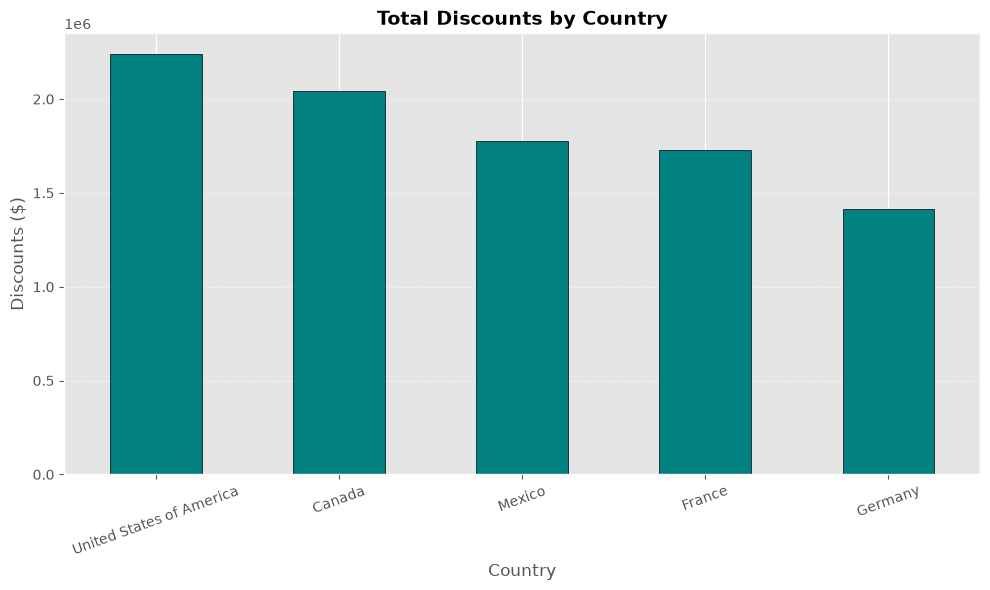

In [36]:
country_discount = (
    df.groupby("Country")["Discounts"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

country_discount.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Total Discounts by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Discounts ($)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

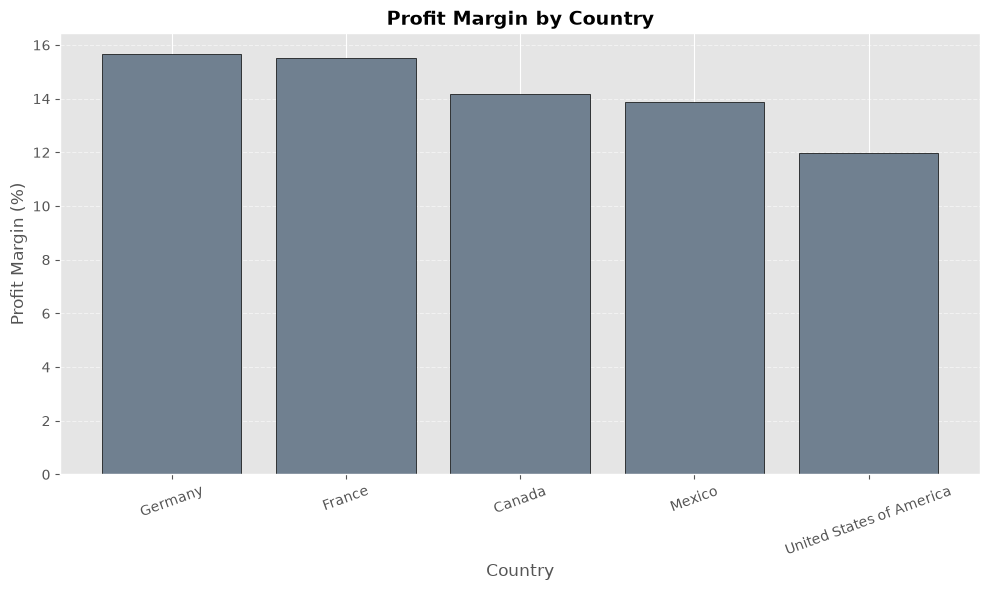

In [39]:
country_analysis = df.groupby("Country").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

country_analysis["Profit Margin (%)"] = (
    country_analysis["Total_Profit"] /
    country_analysis["Total_Sales"] * 100
).round(2)

country_analysis = country_analysis.sort_values(
    "Profit Margin (%)",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    country_analysis.index,
    country_analysis["Profit Margin (%)"],
    color="slategrey",
    edgecolor="black"
)

plt.title("Profit Margin by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

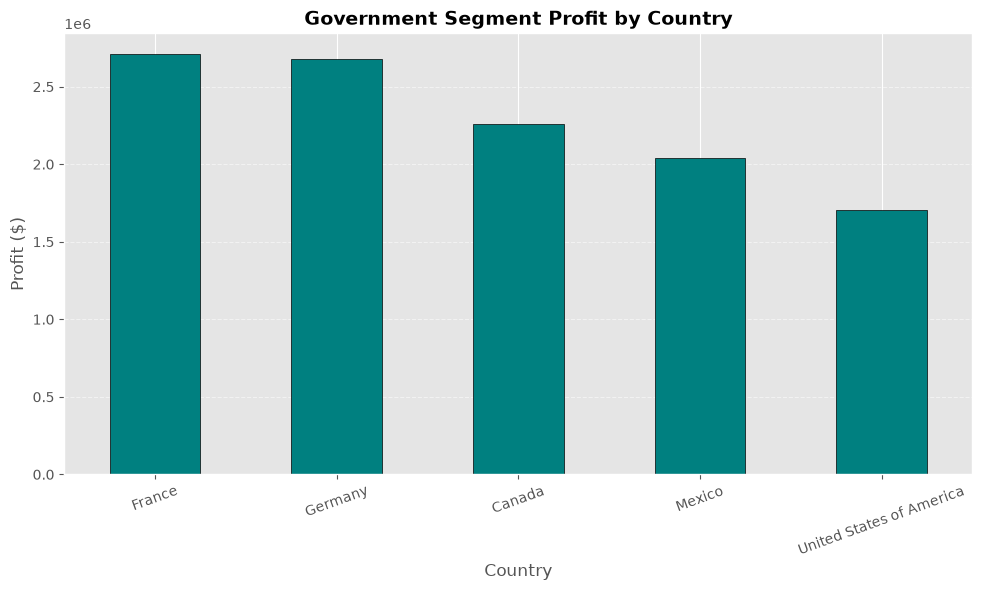

In [41]:
government_profit = (
    df[df["Segment"]=="Government"]
    .groupby("Country")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

government_profit.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Government Segment Profit by Country",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Country")
plt.ylabel("Profit ($)")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

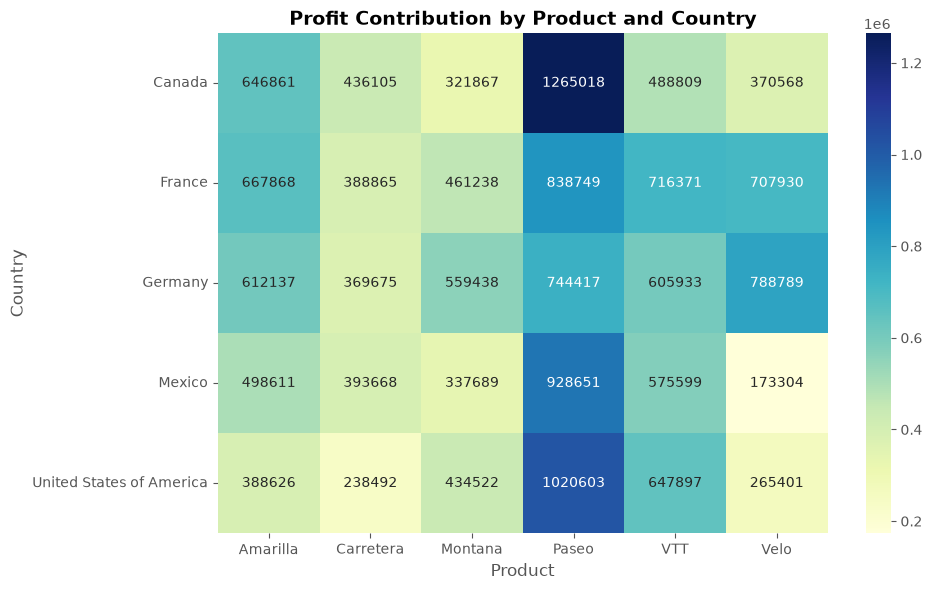

In [42]:
import seaborn as sns

product_profit = pd.pivot_table(
    df,
    values="Profit",
    index="Country",
    columns="Product",
    aggfunc="sum"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    product_profit,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Profit Contribution by Product and Country",
          fontsize=14,
          fontweight="bold")

plt.tight_layout()
plt.show()

# 4. Customer Segment Analysis

## Business Question

Which customer segments contribute the most to the company's sales and profitability?

Understanding customer segment performance helps management identify high-value customer groups, allocate resources effectively, and develop targeted business strategies.

In [43]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Government          5.250426e+07
Small Business      4.242792e+07
Enterprise          1.961169e+07
Midmarket           2.381883e+06
Channel Partners    1.800594e+06
Name: Sales, dtype: float64

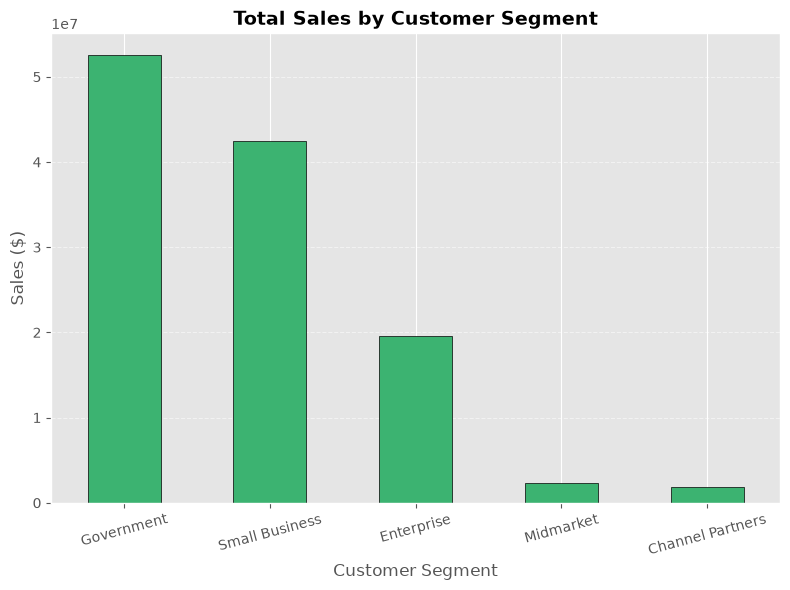

In [44]:
plt.figure(figsize=(8,6))

segment_sales.plot(
    kind="bar",
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Total Sales by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Sales ($)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [45]:
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

segment_profit

Segment
Government          1.138817e+07
Small Business      4.143168e+06
Channel Partners    1.316803e+06
Midmarket           6.601031e+05
Enterprise         -6.145456e+05
Name: Profit, dtype: float64

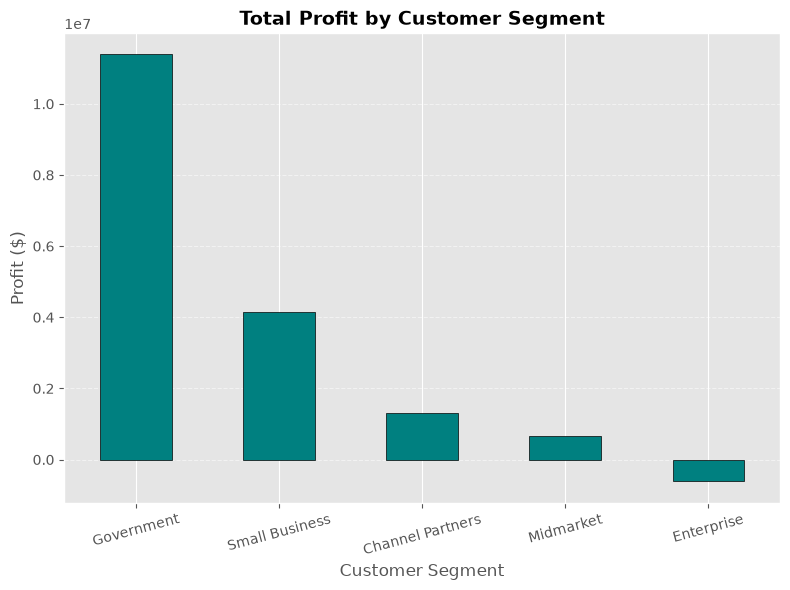

In [46]:
plt.figure(figsize=(8,6))

segment_profit.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Total Profit by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Profit ($)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [49]:
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum"),
    Total_Discounts=("Discounts", "sum")
)

segment_analysis["Profit Margin (%)"] = (
    segment_analysis["Total_Profit"] /
    segment_analysis["Total_Sales"] * 100
).round(2)

segment_analysis.sort_values("Total_Profit", ascending=False)

,Total_Sales,Total_Profit,Units_Sold,Total_Discounts,Profit Margin (%)
Segment,,,,,
Government,5.250426e+07,1.138817e+07,470673.5,3898805.830,21.69
Small Business,4.242792e+07,4.143168e+06,153139.0,3513781.500,9.77
Channel Partners,1.800594e+06,1.316803e+06,161263.5,134568.360,73.13
Midmarket,2.381883e+06,6.601031e+05,172178.0,200786.925,27.71
Enterprise,1.961169e+07,-6.145456e+05,168552.0,1457305.625,-3.13


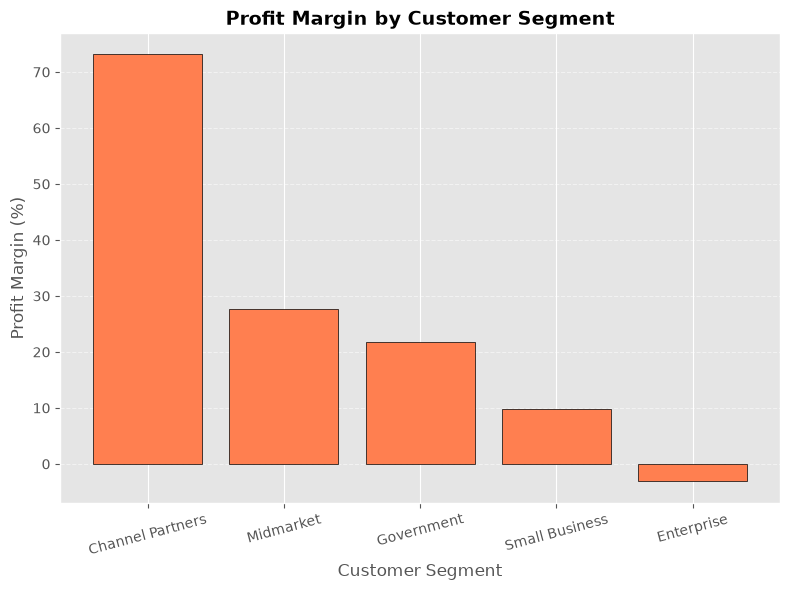

In [52]:
segment_analysis = segment_analysis.sort_values(
    "Profit Margin (%)",
    ascending=False
)

plt.figure(figsize=(8,6))

plt.bar(
    segment_analysis.index,
    segment_analysis["Profit Margin (%)"],
    color="coral",
    edgecolor="black"
)

plt.title("Profit Margin by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Findings

### Key Observations

- The **Government** segment generated the highest total sales among all customer segments.
- The **Government** segment also recorded the highest total profit, significantly outperforming every other segment.
- The profit generated by the Government segment is substantially higher than the remaining customer segments, indicating that it is the company's primary profit driver.
- The **Small Business** segment contributed positively to overall profitability but remained well below the Government segment.
- The **Enterprise** segment recorded an overall loss, making it the only customer segment with negative profitability.
- The large gap between the Government segment and other customer segments suggests that the company relies heavily on Government customers for both revenue and profit.

---

## Business Insights

- The Government segment is the company's most valuable customer segment and should remain a strategic priority.
- Maintaining strong relationships with Government customers could significantly impact future revenue and profitability.
- The Enterprise segment requires immediate business review to determine whether pricing, operational costs, or discount policies are reducing profitability.
- The company should explore opportunities to improve the profitability of other customer segments to reduce dependence on Government customers and create a more balanced revenue portfolio.

In [53]:
segment_analysis.sort_values("Total_Profit", ascending=False)

,Total_Sales,Total_Profit,Units_Sold,Total_Discounts,Profit Margin (%)
Segment,,,,,
Government,5.250426e+07,1.138817e+07,470673.5,3898805.830,21.69
Small Business,4.242792e+07,4.143168e+06,153139.0,3513781.500,9.77
Channel Partners,1.800594e+06,1.316803e+06,161263.5,134568.360,73.13
Midmarket,2.381883e+06,6.601031e+05,172178.0,200786.925,27.71
Enterprise,1.961169e+07,-6.145456e+05,168552.0,1457305.625,-3.13


## Findings

### Key Observations

#### 1. Government Segment is the Primary Business Driver

The **Government** segment generated the highest sales (**$52.50M**) and the highest profit (**$11.39M**) among all customer segments. It also achieved a healthy **profit margin of 21.69%**, making it the company's strongest contributor to both revenue and profitability.

---

#### 2. Small Business is the Second Largest Contributor

The **Small Business** segment generated the second-highest sales (**$42.43M**) and contributed approximately **$4.14M** in profit. Although profitable, its **9.77% profit margin** is considerably lower than the Government segment, indicating lower profitability per dollar of sales.

---

#### 3. Channel Partners Achieved the Highest Profit Margin

Despite generating relatively low sales (**$1.80M**), the **Channel Partners** segment recorded an exceptionally high **profit margin of 73.13%**.

This suggests that Channel Partner transactions are highly profitable, although their overall business volume is currently limited.

---

#### 4. Midmarket Demonstrated Strong Profitability

The **Midmarket** segment achieved a **27.71% profit margin**, the second-highest after Channel Partners. While its sales volume remains relatively small, the segment converts revenue into profit very efficiently.

---

#### 5. Enterprise Segment is Underperforming

The **Enterprise** segment generated substantial sales (**$19.61M**) but recorded an overall **loss of approximately $614.5K**, resulting in a **negative profit margin of -3.13%**.

This indicates that despite strong revenue generation, the Enterprise segment is not financially sustainable under the current pricing, cost structure, or discount strategy.

---

## Business Insights

- The **Government** segment is the company's most valuable customer segment and should remain a strategic priority.
- **Channel Partners** and **Midmarket** demonstrate excellent profitability and may offer opportunities for future expansion.
- The **Small Business** segment contributes significant revenue but has scope to improve its profit margin.
- The **Enterprise** segment requires immediate investigation, as high sales are not translating into positive financial returns.
- The company should aim to diversify revenue sources while maintaining the strong performance of the Government segment.

---

## Recommendations

- Continue investing in the Government segment to maintain its strong revenue and profit contribution.
- Expand the Channel Partners network, as it delivers the highest profit margin despite low sales volume.
- Explore opportunities to increase Midmarket sales while preserving its strong profitability.
- Review the Enterprise segment's pricing strategy, discount policies, and operating costs to address persistent losses.
- Improve profitability in the Small Business segment through cost optimization and targeted pricing strategies.

# 5. Product Performance Analysis

## Business Question

Which products contribute the most to sales and profitability?

Evaluating product performance helps identify the company's best-performing products, optimize product strategy, and improve inventory and marketing decisions.

In [54]:
product_sales = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

product_sales

Product
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Amarilla     1.774712e+07
Montana      1.539080e+07
Carretera    1.381531e+07
Name: Sales, dtype: float64

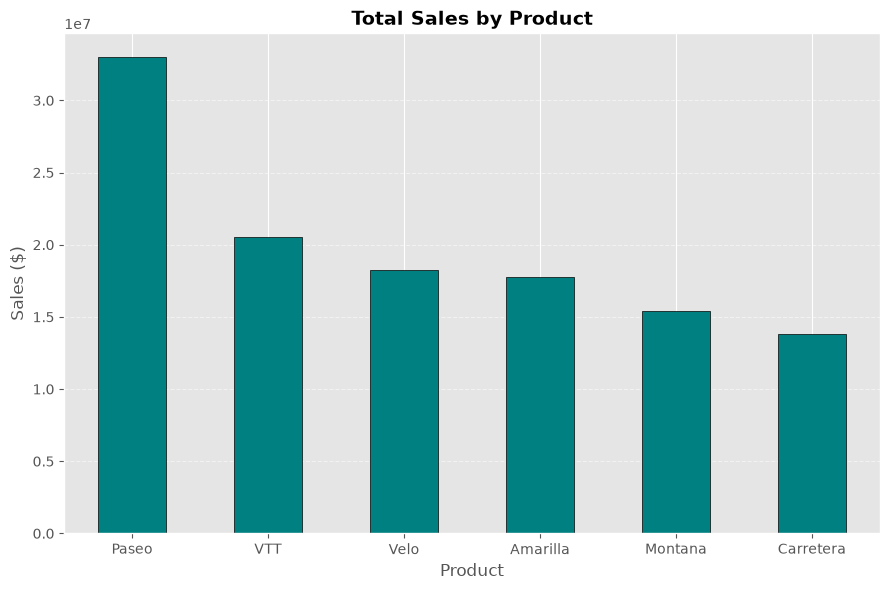

In [56]:
plt.figure(figsize=(9,6))

product_sales.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Total Sales by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [57]:
product_profit = (
    df.groupby("Product")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

product_profit

Product
Paseo        4797437.950
VTT          3034608.020
Amarilla     2814104.060
Velo         2305992.465
Montana      2114754.880
Carretera    1826804.885
Name: Profit, dtype: float64

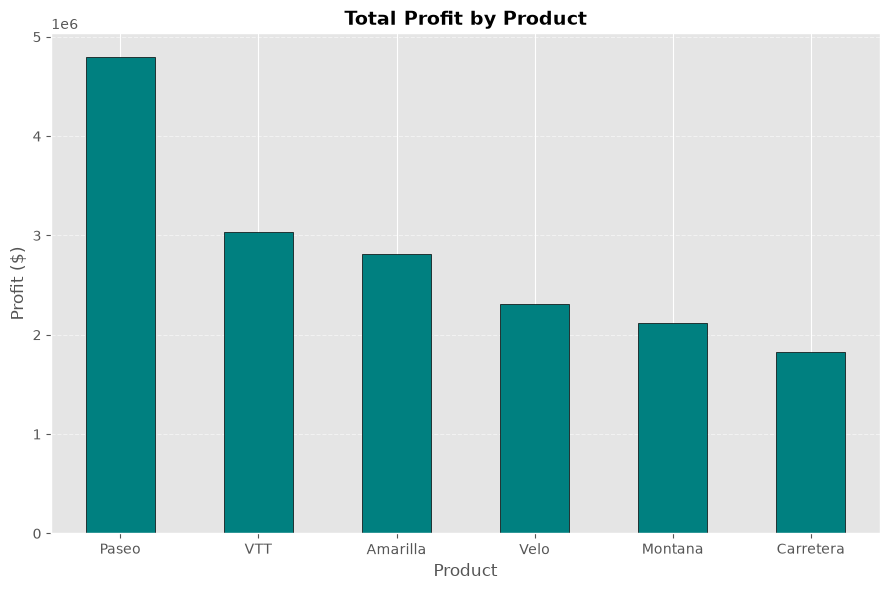

In [58]:
plt.figure(figsize=(9,6))

product_profit.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Total Profit by Product", fontsize=14, fontweight="bold")
plt.xlabel("Product")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Cross-Analysis Insight

Although Paseo is the company's highest-performing product and contributes significantly to profitability in the United States, France achieved the highest overall profit by maintaining strong performance across multiple products rather than relying on a single product.

This diversified product portfolio, combined with lower discount levels and stronger Government segment performance, enabled France to outperform the United States in overall profitability despite generating slightly lower sales.

# 6. Discount Analysis

## Business Question

How do discounts influence sales and profitability?

Discounts are commonly used to increase sales, but excessive discounting can reduce profit margins. This analysis evaluates the relationship between discounts, sales, and profit to identify whether the current discount strategy is effective.

In [59]:
discount_profit = (
    df.groupby("Discount Band")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

discount_profit

Discount Band
Low       6188857.700
Medium    5579522.835
High      3388866.725
Name: Profit, dtype: float64

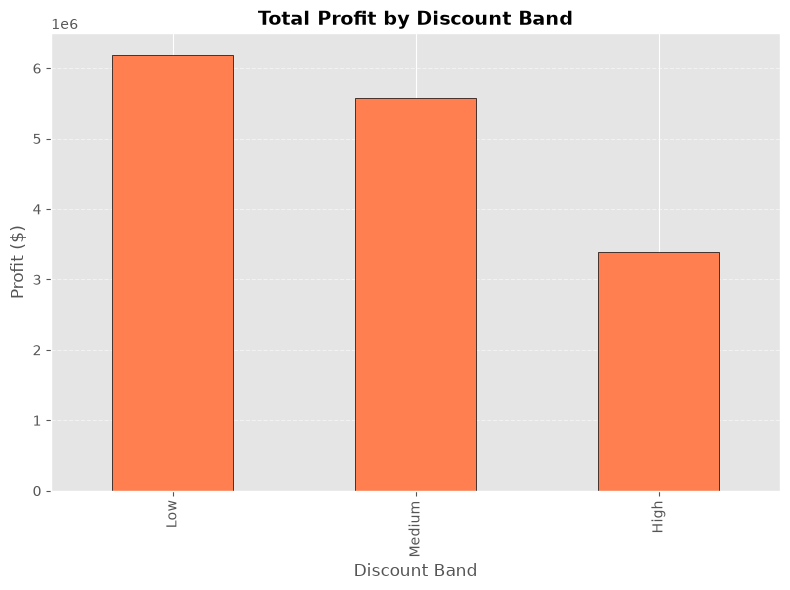

In [60]:
plt.figure(figsize=(8,6))

discount_profit.plot(
    kind="bar",
    color="coral",
    edgecolor="black"
)

plt.title("Total Profit by Discount Band", fontsize=14, fontweight="bold")
plt.xlabel("Discount Band")
plt.ylabel("Profit ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
discount_sales = (
    df.groupby("Discount Band")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

discount_sales

Discount Band
Medium    3.878043e+07
High      3.737249e+07
Low       3.462978e+07
Name: Sales, dtype: float64

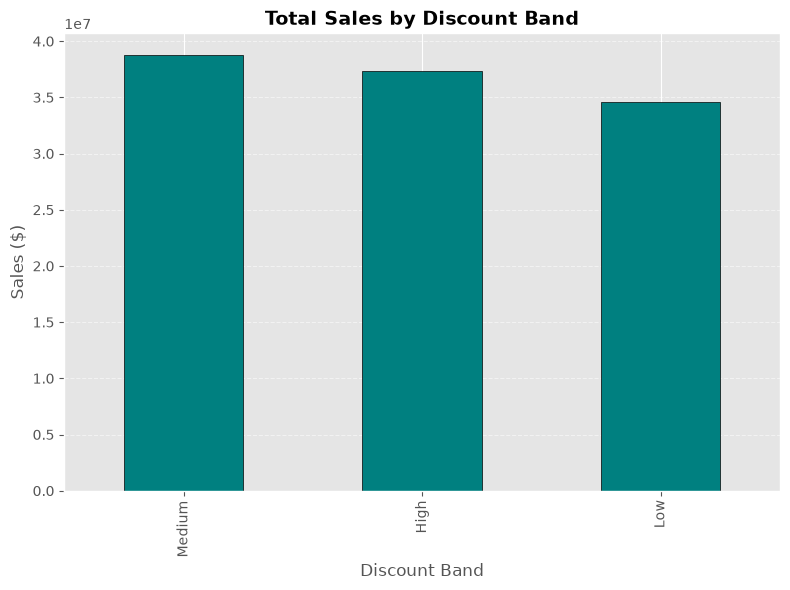

In [62]:
plt.figure(figsize=(8,6))

discount_sales.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Total Sales by Discount Band", fontsize=14, fontweight="bold")
plt.xlabel("Discount Band")
plt.ylabel("Sales ($)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [63]:
discount_analysis = df.groupby("Discount Band").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Units Sold", "sum"),
    Total_Discounts=("Discounts", "sum")
)

discount_analysis["Profit Margin (%)"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"] * 100
).round(2)

discount_analysis.sort_values("Profit_Margin (%)" if "Profit_Margin (%)" in discount_analysis.columns else "Profit Margin (%)", ascending=False)

,Total_Sales,Total_Profit,Units_Sold,Total_Discounts,Profit Margin (%)
Discount Band,,,,,
Low,3.462978e+07,6188857.700,261858.5,885675.800,17.87
Medium,3.878043e+07,5579522.835,379698.5,3002546.165,14.39
High,3.737249e+07,3388866.725,398085.5,5317026.275,9.07


## Findings

### 1. Medium Discounts Generated the Highest Sales

The Medium Discount band generated the highest total sales (**$38.78M**), indicating that moderate discounts effectively encourage customer purchases.

---

### 2. Low Discounts Produced the Highest Profit

The Low Discount band generated the highest total profit (**$6.19M**) and achieved the highest profit margin (**17.87%**).

This suggests that maintaining lower discount levels preserves profitability while still generating strong revenue.

---

### 3. High Discounts Reduced Profitability

Although the High Discount band generated sales comparable to the Medium Discount band, it recorded the lowest total profit (**$3.39M**) and the lowest profit margin (**9.07%**).

This indicates that aggressive discounting significantly reduces overall profitability.

---

### 4. Higher Discounts Do Not Guarantee Better Business Performance

Increasing discounts beyond a moderate level did not produce meaningful improvements in sales but resulted in substantial reductions in profit.

This highlights the importance of balancing customer incentives with sustainable profit margins.

---

## Business Insights

- Moderate discounts appear to be the most effective strategy for balancing revenue growth and profitability.
- Excessive discounting erodes profit margins and should be applied selectively.
- Lower discount levels deliver the strongest financial performance by maximizing profit while maintaining healthy sales.
- The company should regularly evaluate discount policies to ensure they support long-term profitability rather than short-term sales growth.

---

## Recommendations

- Continue using moderate discounts as the primary pricing strategy.
- Restrict high-discount campaigns to specific promotional events or inventory clearance.
- Monitor the financial impact of discount campaigns before expanding them.
- Establish profit margin targets alongside sales targets when designing future pricing strategies.

# 7. Time Series Analysis

## Business Question

How does business performance change over time?

Analyzing monthly and yearly trends helps identify seasonal patterns, periods of strong or weak performance, and long-term business growth. These insights enable management to plan inventory, marketing campaigns, and resource allocation more effectively.

In [64]:
monthly_sales = (
    df.groupby(["Month Number", "Month Name"])["Sales"]
      .sum()
      .reset_index()
      .sort_values("Month Number")
)

monthly_sales

,Month Number,Month Name,Sales
0,1,January,6607761.68
1,2,February,7297531.39
2,3,March,5586859.87
3,4,April,6964775.07
4,5,May,6210211.06
5,6,June,9518893.82
6,7,July,8102920.18
7,8,August,5864622.42
8,9,September,10882697.27
9,10,October,21671431.02


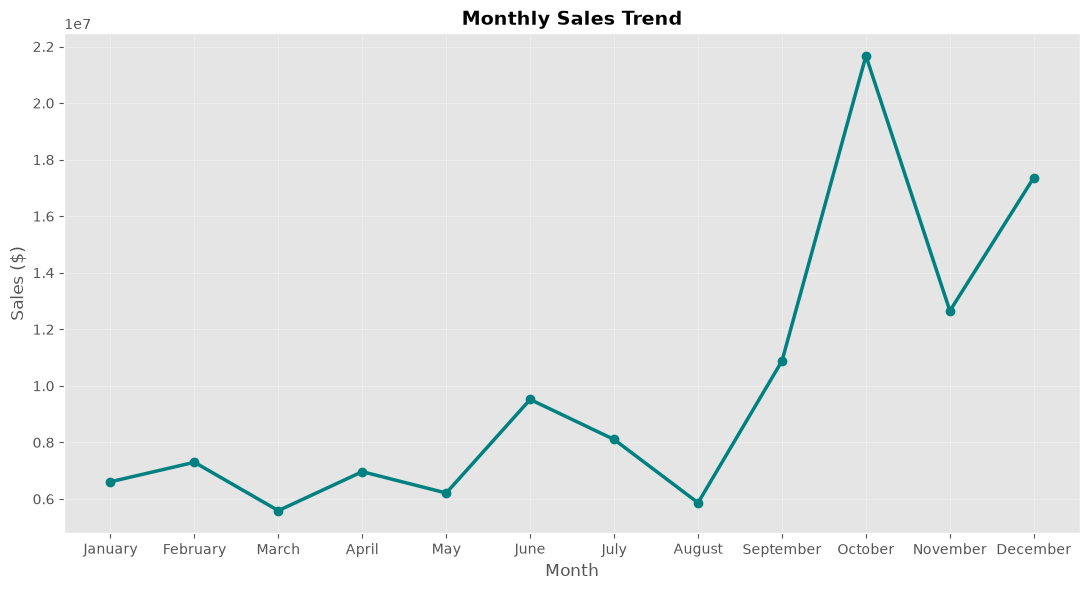

In [65]:
plt.figure(figsize=(11,6))

plt.plot(
    monthly_sales["Month Name"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2.5,
    color="teal"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
monthly_profit = (
    df.groupby(["Month Number", "Month Name"])["Profit"]
      .sum()
      .reset_index()
      .sort_values("Month Number")
)

monthly_profit

,Month Number,Month Name,Profit
0,1,January,814028.68
1,2,February,1148547.39
2,3,March,669866.87
3,4,April,929984.57
4,5,May,828640.06
5,6,June,1473753.82
6,7,July,923865.68
7,8,August,791066.42
8,9,September,1786735.27
9,10,October,3439781.02


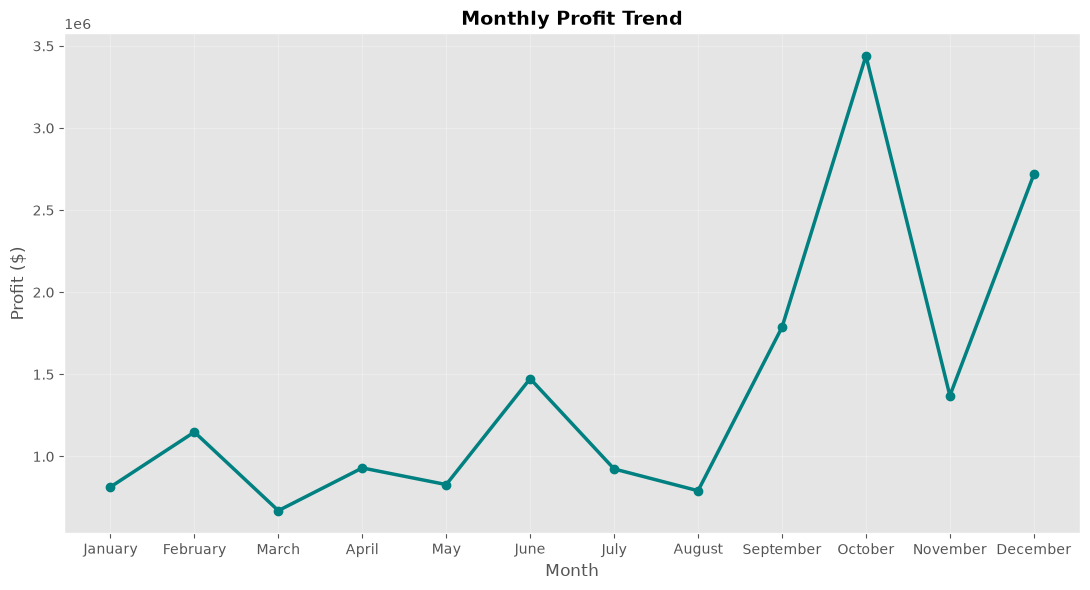

In [67]:
plt.figure(figsize=(11,6))

plt.plot(
    monthly_profit["Month Name"],
    monthly_profit["Profit"],
    marker="o",
    linewidth=2.5,
    color="teal"
)

plt.title("Monthly Profit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Profit ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
#yearly
year_sales = (
    df.groupby("Year")["Sales"]
      .sum()
)

year_sales

Year
2013    26415255.51
2014    92311094.75
Name: Sales, dtype: float64

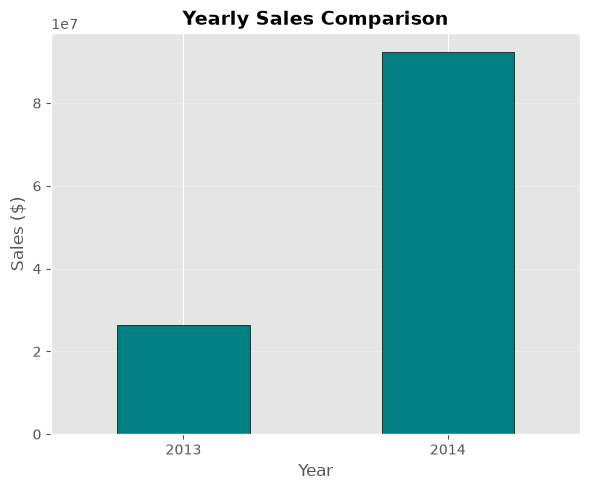

In [69]:
plt.figure(figsize=(6,5))

year_sales.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Yearly Sales Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [70]:
year_profit = (
    df.groupby("Year")["Profit"]
      .sum()
)

year_profit

Year
2013     3878464.51
2014    13015237.75
Name: Profit, dtype: float64

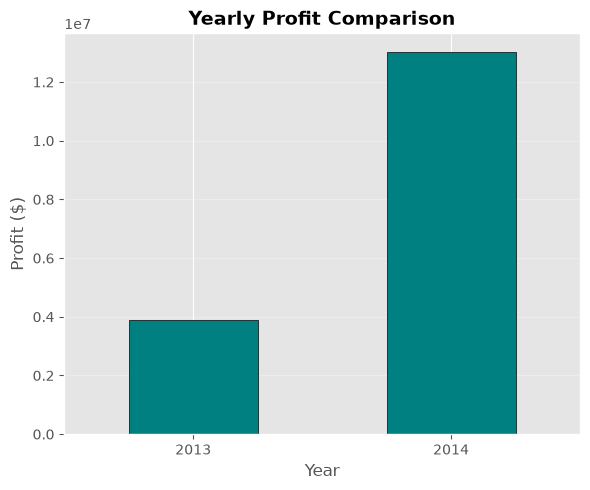

In [71]:
plt.figure(figsize=(6,5))

year_profit.plot(
    kind="bar",
    color="teal",
    edgecolor="black"
)

plt.title("Yearly Profit Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Profit ($)")
plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
monthly_summary = (
    df.groupby(["Month Number", "Month Name"])
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .reset_index()
      .sort_values("Month Number")
)

monthly_summary

,Month Number,Month Name,Sales,Profit
0,1,January,6607761.68,814028.68
1,2,February,7297531.39,1148547.39
2,3,March,5586859.87,669866.87
3,4,April,6964775.07,929984.57
4,5,May,6210211.06,828640.06
5,6,June,9518893.82,1473753.82
6,7,July,8102920.18,923865.68
7,8,August,5864622.42,791066.42
8,9,September,10882697.27,1786735.27
9,10,October,21671431.02,3439781.02


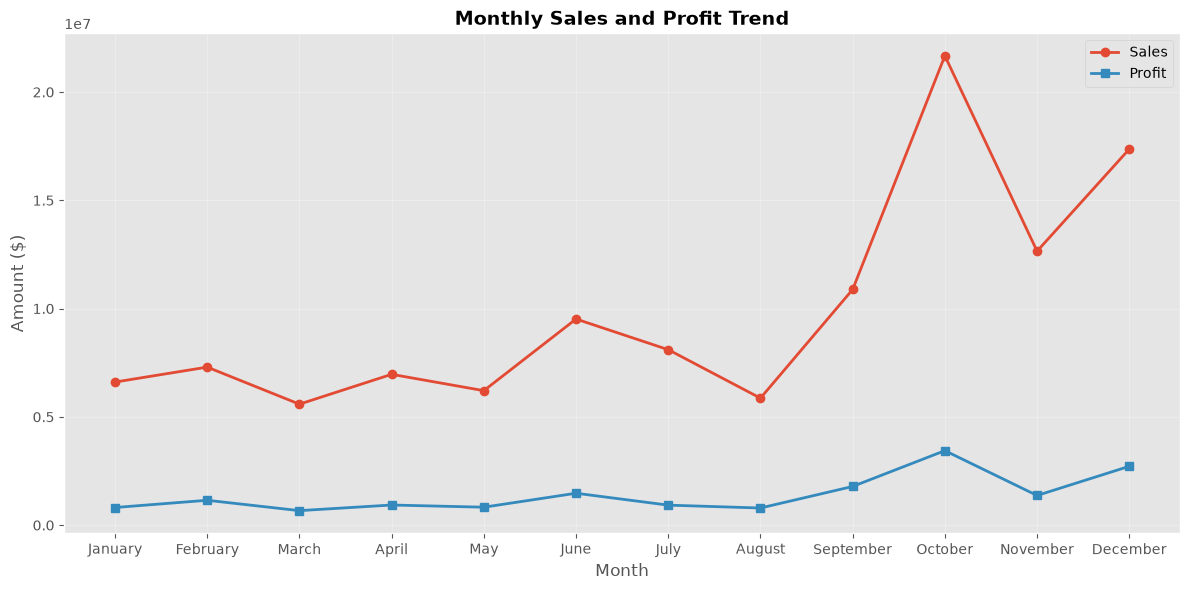

In [73]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_summary["Month Name"],
    monthly_summary["Sales"],
    marker="o",
    linewidth=2,
    label="Sales"
)

plt.plot(
    monthly_summary["Month Name"],
    monthly_summary["Profit"],
    marker="s",
    linewidth=2,
    label="Profit"
)

plt.title("Monthly Sales and Profit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Findings

### 1. Sales and Profit Increased Significantly During the Final Quarter

Business performance improved considerably during the last quarter (October–December), with both sales and profit reaching their highest levels of the year.

This indicates a strong seasonal pattern in business performance.

---

### 2. October Was the Best-Performing Month

October recorded the highest monthly sales (**$21.67M**) and the highest monthly profit (**$3.44M**), making it the strongest-performing month in the dataset.

The substantial increase compared to previous months suggests the influence of seasonal demand, promotional campaigns, or increased customer purchasing activity.

---

### 3. December Also Delivered Strong Performance

December generated the second-highest monthly sales (**$17.37M**) and the second-highest monthly profit (**$2.72M**).

This reinforces the presence of strong year-end business activity.

---

### 4. September Marked the Beginning of Strong Growth

Sales and profit increased noticeably from September onward, indicating the beginning of the company's peak business period.

---

### 5. Early-Year Performance Was Comparatively Lower

The first half of the year recorded relatively stable but lower sales and profit levels compared to the final quarter.

March generated the lowest monthly sales (**$5.59M**) and one of the lowest monthly profit values (**$0.67M**), suggesting weaker customer demand during that period.

---

## Business Insights

- The company experiences clear seasonal demand, with the strongest performance occurring between **September and December**.
- October is the company's peak business month and contributes significantly to annual revenue and profit.
- The first half of the year presents an opportunity for management to introduce targeted marketing campaigns and promotional strategies to improve sales performance.
- Resource planning, inventory management, and staffing should be aligned with the increased demand observed during the final quarter.

In [74]:
year_profit

Year
2013     3878464.51
2014    13015237.75
Name: Profit, dtype: float64

### 6. Yearly Performance Comparison

The dataset indicates that **2014 generated substantially higher total profit ($13.02M) than 2013 ($3.88M).**

However, this comparison should be interpreted with caution because the dataset contains a significantly larger number of records for 2014 than for 2013. Therefore, the higher annual profit may partially reflect greater data coverage rather than purely improved business performance.

Despite this limitation, the available data suggests stronger business activity during 2014.

# 8. Correlation Analysis

## Business Question

How are key business metrics related to each other?

Correlation analysis helps identify relationships between sales, profit, discounts, costs, and units sold. These insights support pricing, marketing, and operational decision-making.

In [75]:
correlation = df[
    ["Units Sold",
     "Gross Sales",
     "Discounts",
     "Sales",
     "COGS",
     "Profit"]
].corr()

correlation

,Units Sold,Gross Sales,Discounts,Sales,COGS,Profit
Units Sold,1.000000,0.327221,0.253048,0.326914,0.331694,0.228437
Gross Sales,0.327221,1.000000,0.782485,0.998174,0.994519,0.784508
Discounts,0.253048,0.782485,1.000000,0.743447,0.782930,0.383087
Sales,0.326914,0.998174,0.743447,1.000000,0.992244,0.805462
COGS,0.331694,0.994519,0.782930,0.992244,1.000000,0.725544
Profit,0.228437,0.784508,0.383087,0.805462,0.725544,1.000000


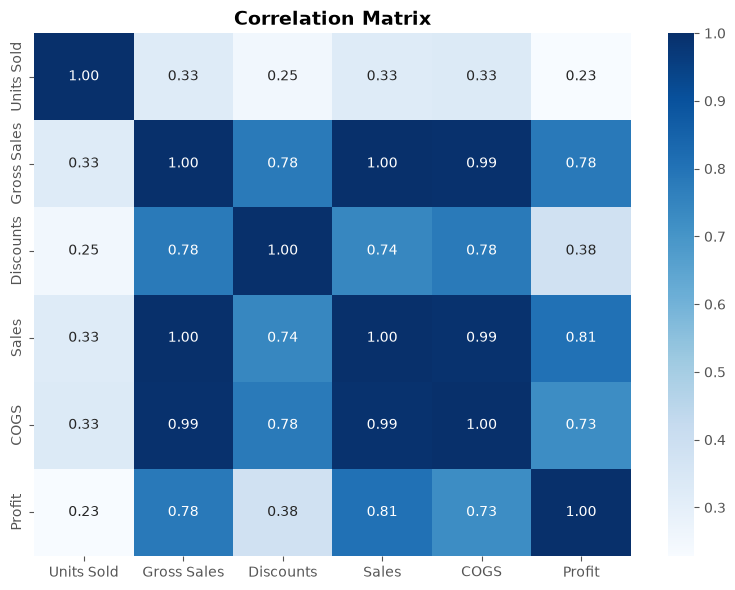

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

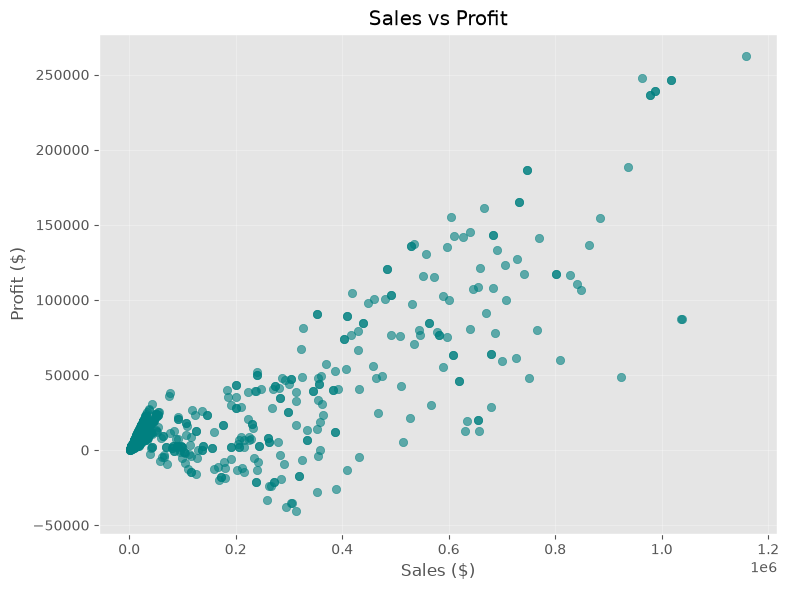

In [78]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.6,
    color="teal"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales ($)")
plt.ylabel("Profit ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

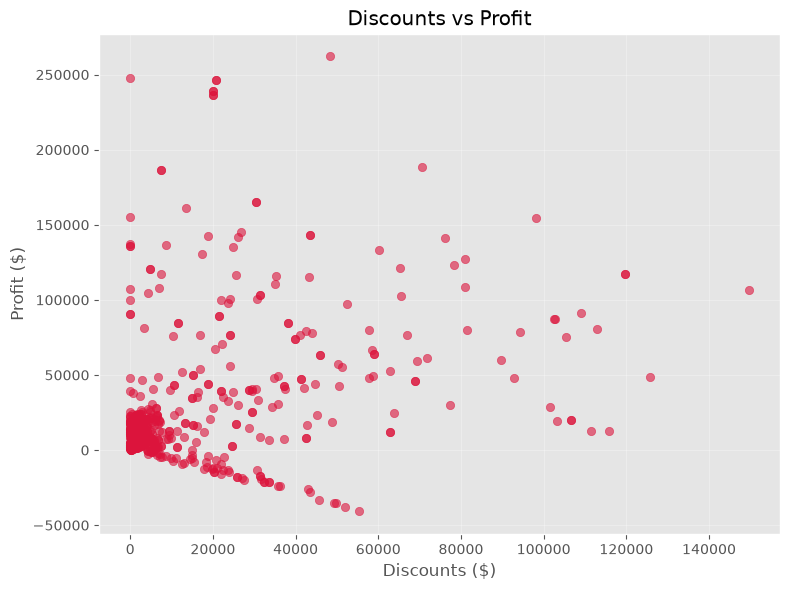

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discounts"],
    df["Profit"],
    alpha=0.6,
    color="crimson"
)

plt.title("Discounts vs Profit")
plt.xlabel("Discounts ($)")
plt.ylabel("Profit ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

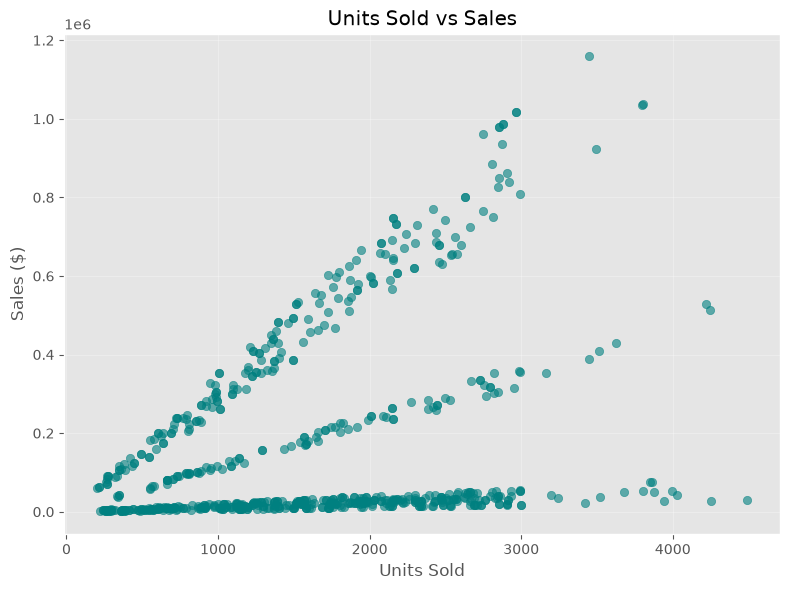

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Units Sold"],
    df["Sales"],
    alpha=0.6,
    color="teal"
)

plt.title("Units Sold vs Sales")
plt.xlabel("Units Sold")
plt.ylabel("Sales ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Overall Conclusion

## Summary

The analysis identified several important business patterns across countries, customer segments, products, discount strategies, and time.

### Key Findings

- The United States generated the highest sales, while France achieved the highest profitability through a balanced product portfolio and controlled discounting.
- The Government segment was the company's primary revenue and profit driver.
- Paseo emerged as the highest-performing product in terms of both sales and profit.
- Moderate discounts increased sales effectively, while excessive discounts significantly reduced profit margins.
- Business performance exhibited strong seasonality, with October and December delivering the highest sales and profits.
- The dataset indicates stronger business activity during 2014; however, comparisons should be interpreted cautiously because of unequal data coverage across years.

## Final Recommendations

- Continue investing in Government customers and high-performing products such as Paseo.
- Expand high-margin customer segments like Channel Partners while improving the profitability of the Enterprise segment.
- Optimize discount strategies by emphasizing moderate discounts instead of aggressive price reductions.
- Prepare inventory, staffing, and marketing campaigns ahead of the September–December peak season.
- Monitor profitability alongside revenue to ensure sustainable long-term business growth.